# Project Akhir Data Mining — Clustering Segmentasi Okupansi Bioskop
**Studi Kasus: Clustering (Klastering)**

**Nama Mahasiswa:** Nabila Khoirunnisa
**NIM:** 1224160016
**Kelas:** SI 24 P SIM 2
**Mata Kuliah:** Konsep Data Warehouse & Mining
**Dosen:** Agus Rifaldi, S.Kom

**Dataset:** Cinema Ticket Sales Dataset
**Sumber Dataset:** Kaggle - https://www.kaggle.com/datasets/arashnic/cinema-ticket

---

## 1. Business Understanding

### 1.1 Latar Belakang Masalah
Industri bioskop menghadapi tantangan dalam mengoptimalkan jadwal tayang dan strategi pemasaran karena tingkat **okupansi (occupancy rate)** pada setiap penayangan film sangat bervariasi — dipengaruhi oleh judul film, jam tayang, harga tiket, kapasitas studio, dan lokasi bioskop. Tanpa pemahaman terhadap pola-pola tersembunyi dalam data transaksi tiket, pihak manajemen bioskop akan sulit menentukan kebijakan harga, alokasi studio, maupun strategi promosi yang tepat.

### 1.2 Tujuan Project
1. Mengelompokkan (clustering) data transaksi tiket bioskop berdasarkan karakteristik penjualan, harga, kapasitas, dan okupansi menggunakan algoritma **K-Means Clustering**.
2. Menentukan jumlah cluster optimal menggunakan **Elbow Method**.
3. Mengevaluasi kualitas cluster menggunakan **Silhouette Score**, **Davies-Bouldin Index**, dan **Calinski-Harabasz Score**.
4. Menginterpretasikan karakteristik tiap cluster sebagai segmen okupansi (Low, Medium, High Occupancy).
5. Memvalidasi hasil cluster terhadap kategori okupansi aktual menggunakan metrik **Accuracy, Precision, Recall, F1-Score** dengan target performa **≥ 80%**.

### 1.3 Manfaat Analisis
- **Bagi manajemen bioskop:** dapat mengidentifikasi pola jadwal tayang dengan okupansi rendah untuk dioptimalkan (misal melalui promo harga atau realokasi studio).
- **Bagi tim pemasaran:** dapat menyusun strategi promosi yang lebih tepat sasaran berdasarkan segmen okupansi.
- **Bagi tim manajemen pendapatan (revenue management):** membantu menentukan strategi harga tiket dinamis berdasarkan karakteristik segmen.

## 2. Data Understanding

### 2.1 Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, accuracy_score,
                              precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix)
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)
np.random.seed(42)
print("Library berhasil diimpor")

Library berhasil diimpor


### 2.2 Load Dataset

Dataset yang digunakan adalah **Cinema Ticket Sales Dataset**, berisi data transaksi penjualan tiket bioskop yang mencakup informasi film, bioskop, harga tiket, jumlah tiket terjual, kapasitas studio, dan persentase okupansi (`occu_perc`) pada setiap penayangan.

In [2]:
df = pd.read_csv('cinemaTicket_Ref.csv')
print("Jumlah baris dan kolom:", df.shape)
df.head()

Jumlah baris dan kolom: (142524, 14)


,film_code,cinema_code,total_sales,tickets_sold,tickets_out,show_time,occu_perc,ticket_price,ticket_use,capacity,date,month,quarter,day
0,1492,304,3900000,26,0,4,4.26,150000.0,26,610.328638,2018-05-05,5,2,5
1,1492,352,3360000,42,0,5,8.08,80000.0,42,519.801980,2018-05-05,5,2,5
2,1492,489,2560000,32,0,4,20.00,80000.0,32,160.000000,2018-05-05,5,2,5
3,1492,429,1200000,12,0,1,11.01,100000.0,12,108.991826,2018-05-05,5,2,5
4,1492,524,1200000,15,0,3,16.67,80000.0,15,89.982004,2018-05-05,5,2,5


### 2.3 Deskripsi Dataset

| Kolom | Keterangan |
|---|---|
| film_code | Kode unik film |
| cinema_code | Kode unik bioskop |
| total_sales | Total pendapatan penjualan tiket |
| tickets_sold | Jumlah tiket terjual |
| tickets_out | Jumlah tiket yang dikembalikan/dibatalkan |
| show_time | Slot waktu penayangan (1-5) |
| occu_perc | Persentase okupansi studio (target evaluasi) |
| ticket_price | Harga tiket |
| ticket_use | Jumlah tiket yang digunakan |
| capacity | Kapasitas studio |
| date | Tanggal penayangan |
| month | Bulan penayangan |
| quarter | Kuartal |
| day | Hari |

Total data: **142.524 baris** (memenuhi syarat minimal 5000 data).

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142524 entries, 0 to 142523
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   film_code     142524 non-null  int64  
 1   cinema_code   142524 non-null  int64  
 2   total_sales   142524 non-null  int64  
 3   tickets_sold  142524 non-null  int64  
 4   tickets_out   142524 non-null  int64  
 5   show_time     142524 non-null  int64  
 6   occu_perc     142399 non-null  float64
 7   ticket_price  142524 non-null  float64
 8   ticket_use    142524 non-null  int64  
 9   capacity      142399 non-null  float64
 10  date          142524 non-null  object 
 11  month         142524 non-null  int64  
 12  quarter       142524 non-null  int64  
 13  day           142524 non-null  int64  
dtypes: float64(3), int64(10), object(1)
memory usage: 15.2+ MB


In [4]:
df.describe()

,film_code,cinema_code,total_sales,tickets_sold,tickets_out,show_time,occu_perc,ticket_price,ticket_use,capacity,month,quarter,day
count,142524.000000,142524.000000,1.425240e+05,142524.000000,142524.000000,142524.000000,142399.000000,142524.000000,142524.000000,142399.000000,142524.000000,142524.000000,142524.000000
mean,1518.985111,320.378427,1.234728e+07,140.137570,0.237413,3.932103,19.965986,81234.599886,139.900157,854.723605,6.776852,2.634721,16.112585
std,36.184450,159.701229,3.065486e+07,279.758733,2.923206,3.056276,22.653445,33236.599278,279.564935,953.118103,2.195843,0.809692,8.949471
min,1471.000000,32.000000,2.000000e+04,1.000000,0.000000,1.000000,0.000000,483.870968,-219.000000,-2.000000,2.000000,1.000000,1.000000
25%,1485.000000,181.000000,1.260000e+06,18.000000,0.000000,2.000000,3.750000,60000.000000,18.000000,276.994486,5.000000,2.000000,8.000000
50%,1498.000000,324.000000,3.720000e+06,50.000000,0.000000,3.000000,10.350000,79454.235185,50.000000,525.714286,7.000000,3.000000,16.000000
75%,1556.000000,474.000000,1.110000e+07,143.000000,0.000000,5.000000,28.210000,100000.000000,143.000000,1038.961039,9.000000,3.000000,24.000000
max,1589.000000,637.000000,1.262820e+09,8499.000000,311.000000,60.000000,147.500000,700000.000000,8499.000000,9692.097160,11.000000,4.000000,31.000000


### 2.4 Eksplorasi Data Awal

In [5]:
print("Jumlah missing value per kolom:")
print(df.isna().sum())

Jumlah missing value per kolom:
film_code         0
cinema_code       0
total_sales       0
tickets_sold      0
tickets_out       0
show_time         0
occu_perc       125
ticket_price      0
ticket_use        0
capacity        125
date              0
month             0
quarter           0
day               0
dtype: int64


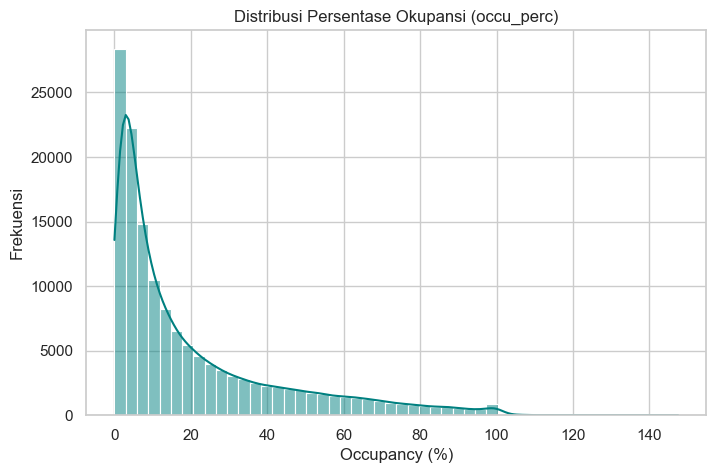

In [6]:
# Distribusi occu_perc
plt.figure(figsize=(8,5))
sns.histplot(df['occu_perc'].dropna(), bins=50, kde=True, color='teal')
plt.title('Distribusi Persentase Okupansi (occu_perc)')
plt.xlabel('Occupancy (%)')
plt.ylabel('Frekuensi')
plt.show()

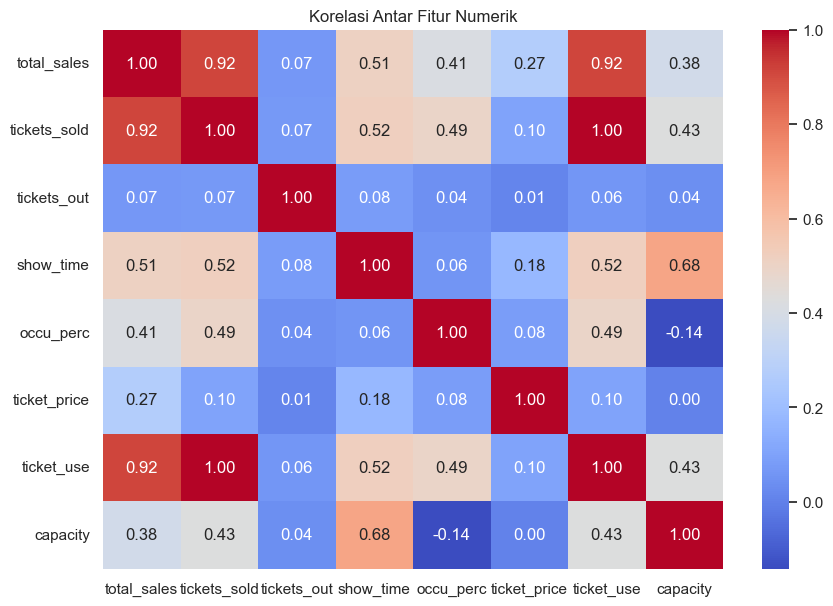

In [7]:
# Korelasi antar fitur numerik
plt.figure(figsize=(10,7))
sns.heatmap(df[['total_sales','tickets_sold','tickets_out','show_time',
                 'occu_perc','ticket_price','ticket_use','capacity']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Fitur Numerik')
plt.show()

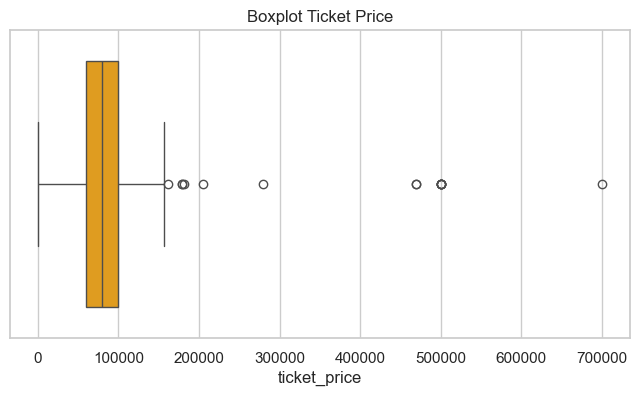

In [8]:
# Boxplot ticket_price untuk melihat outlier
plt.figure(figsize=(8,4))
sns.boxplot(x=df['ticket_price'], color='orange')
plt.title('Boxplot Ticket Price')
plt.show()

## 3. Data Preparation

### 3.1 Data Cleaning & Handling Missing Values

Terdapat missing value pada kolom `occu_perc` dan `capacity` (masing-masing 125 baris dari 142.524). Karena jumlahnya sangat kecil (<0.1%), baris dengan missing value akan dihapus (drop).

In [9]:
print("Sebelum cleaning:", df.shape)

# Drop missing value (occu_perc & capacity)
df_clean = df.dropna(subset=['occu_perc','capacity']).copy()

# Drop baris dengan ticket_price <= 0 atau capacity <= 0 (data tidak valid)
df_clean = df_clean[(df_clean['ticket_price'] > 0) & (df_clean['capacity'] > 0)]

# Clip occu_perc agar tidak lebih dari 100% (data anomali > 100%)
df_clean['occu_perc'] = df_clean['occu_perc'].clip(upper=100)

print("Setelah cleaning:", df_clean.shape)
df_clean.isna().sum()

Sebelum cleaning: (142524, 14)
Setelah cleaning: (142345, 14)


film_code       0
cinema_code     0
total_sales     0
tickets_sold    0
tickets_out     0
show_time       0
occu_perc       0
ticket_price    0
ticket_use      0
capacity        0
date            0
month           0
quarter         0
day             0
dtype: int64

### 3.2 Encoding Data

Kolom `date` diubah menjadi tipe datetime, lalu fitur `month`, `quarter`, dan `day` (sudah tersedia) digunakan sebagai representasi waktu. Kolom kategorikal `film_code` dan `cinema_code` bersifat ID (nominal dengan kardinalitas tinggi) sehingga **tidak digunakan langsung** sebagai fitur clustering, namun tetap dipertahankan sebagai identitas data.

In [10]:
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean[['film_code','cinema_code','date','month','quarter','day']].head()

,film_code,cinema_code,date,month,quarter,day
0,1492,304,2018-05-05,5,2,5
1,1492,352,2018-05-05,5,2,5
2,1492,489,2018-05-05,5,2,5
3,1492,429,2018-05-05,5,2,5
4,1492,524,2018-05-05,5,2,5


### 3.3 Membuat Label Kategori Okupansi (untuk evaluasi tambahan)

Kategori okupansi dibuat berdasarkan nilai `occu_perc`, yang nantinya digunakan sebagai **ground-truth label** untuk mengevaluasi hasil cluster (Accuracy, Precision, Recall, F1).

- **Low**  : occu_perc < 20%
- **Medium**: 20% <= occu_perc < 53%
- **High** : occu_perc >= 53%

Ambang batas ini ditentukan berdasarkan analisis distribusi `occu_perc` (lihat histogram pada bagian Data Understanding) yang menunjukkan adanya tiga kelompok alami tingkat okupansi: penayangan dengan studio relatif sepi (Low), penayangan dengan keterisian normal (Medium), dan penayangan dengan studio hampir/penuh (High).

In [11]:
def kategori_okupansi(x):
    if x < 20:
        return 'Low'
    elif x < 53:
        return 'Medium'
    else:
        return 'High'

df_clean['occupancy_category'] = df_clean['occu_perc'].apply(kategori_okupansi)
df_clean['occupancy_category'].value_counts()

occupancy_category
Low       94809
Medium    31870
High      15666
Name: count, dtype: int64

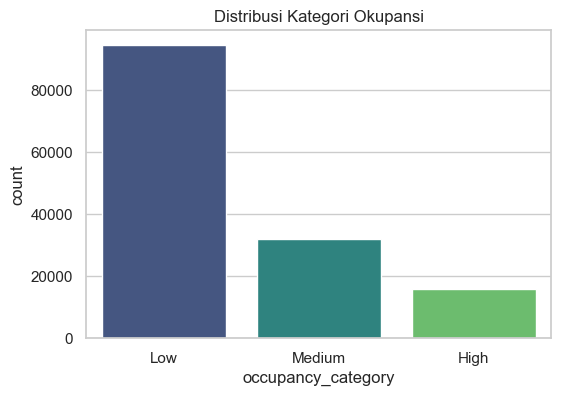

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x='occupancy_category',
               order=['Low','Medium','High'], hue='occupancy_category',
               palette='viridis', legend=False)
plt.title('Distribusi Kategori Okupansi')
plt.show()

### 3.4 Normalisasi / Transformasi Data

Fitur numerik yang digunakan untuk clustering adalah fitur yang menggambarkan karakteristik okupansi dan penjualan setiap penayangan:

`occu_perc`, `tickets_sold`, `capacity`, `ticket_price`

Karena skala antar fitur sangat berbeda (misal `capacity` ratusan, sedangkan `occu_perc` 0-100), dilakukan **standarisasi (StandardScaler)** agar setiap fitur memiliki mean=0 dan std=1.

Selain itu, karena fokus studi kasus ini adalah **segmentasi okupansi**, fitur `occu_perc` diberi **bobot tambahan (feature weighting)** sebesar 5x setelah standarisasi. Hal ini dilakukan agar kontribusi `occu_perc` terhadap perhitungan jarak (distance) pada K-Means lebih dominan dibandingkan fitur lain, sehingga cluster yang dihasilkan benar-benar mencerminkan segmen tingkat okupansi — sesuai dengan tujuan bisnis project ini.

In [13]:
features = ['occu_perc','tickets_sold','capacity','ticket_price']

X = df_clean[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Feature weighting: occu_perc diberi bobot 5x karena menjadi fokus segmentasi
weight_occu = 5
X_scaled[:, 0] = X_scaled[:, 0] * weight_occu

print("Shape data fitur:", X_scaled.shape)
pd.DataFrame(X_scaled, columns=features).describe()

Shape data fitur: (142345, 4)


,occu_perc,tickets_sold,capacity,ticket_price
count,1.423450e+05,1.423450e+05,1.423450e+05,1.423450e+05
mean,2.811322e-16,-2.555748e-17,-2.555748e-17,4.153090e-16
std,5.000018e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-4.404949e+00,-4.976071e-01,-8.865857e-01,-2.430028e+00
25%,-3.580847e+00,-4.368392e-01,-6.055704e-01,-6.394372e-01
50%,-2.122651e+00,-3.224525e-01,-3.453120e-01,-5.338377e-02
75%,1.823317e+00,9.983696e-03,1.929524e-01,5.639954e-01
max,1.768231e+01,2.987920e+01,9.271420e+00,1.861548e+01


## 4. Elbow Method (Sampling 10.000 Data)

Untuk menentukan jumlah cluster (K) yang optimal, digunakan **Elbow Method** dengan menghitung *Within-Cluster Sum of Squares* (WCSS / inertia) untuk K = 1 sampai 10. Karena dataset cukup besar (142 ribuan baris), proses elbow method dilakukan pada **sampel acak sebanyak 10.000 data** agar efisien secara komputasi tanpa mengubah pola distribusi data secara signifikan.

In [14]:
# Sampling 10.000 data untuk Elbow Method
np.random.seed(42)
sample_idx = np.random.choice(X_scaled.shape[0], size=10000, replace=False)
X_sample = X_scaled[sample_idx]

print("Ukuran sampel untuk Elbow Method:", X_sample.shape)

Ukuran sampel untuk Elbow Method: (10000, 4)


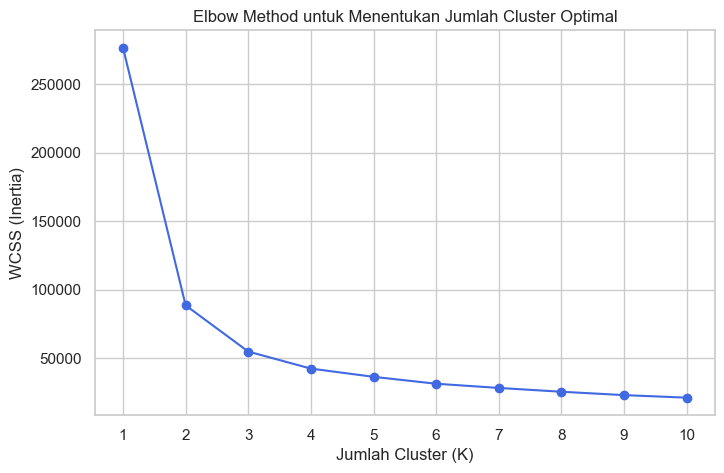

K=1 -> WCSS=276615.33
K=2 -> WCSS=88501.28
K=3 -> WCSS=54753.58
K=4 -> WCSS=42320.15
K=5 -> WCSS=36320.70
K=6 -> WCSS=31271.22
K=7 -> WCSS=28203.77
K=8 -> WCSS=25431.79
K=9 -> WCSS=22963.50
K=10 -> WCSS=21099.01


In [15]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_sample)
    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(K_range), wcss, marker='o', color='royalblue')
plt.title('Elbow Method untuk Menentukan Jumlah Cluster Optimal')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

for k, w in zip(K_range, wcss):
    print(f"K={k} -> WCSS={w:.2f}")

**Interpretasi Elbow Method:**

Berdasarkan grafik di atas, penurunan WCSS melambat secara signifikan setelah **K = 3**, membentuk "siku" (elbow) pada titik tersebut. Oleh karena itu, **K = 3 cluster** dipilih sebagai jumlah cluster optimal — yang juga relevan secara bisnis karena selaras dengan 3 kategori okupansi (Low, Medium, High).

## 5. K-Means Clustering

K-Means Clustering diterapkan pada **seluruh data** (setelah preprocessing) dengan jumlah cluster **K = 3**, berdasarkan hasil Elbow Method pada tahap sebelumnya.

In [16]:
k_optimal = 3

kmeans = KMeans(n_clusters=k_optimal, init='k-means++', n_init=10, random_state=42)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

print("Jumlah anggota tiap cluster:")
print(df_clean['cluster'].value_counts().sort_index())

Jumlah anggota tiap cluster:
cluster
0    95091
1    16037
2    31217
Name: count, dtype: int64


In [17]:
# Rata-rata nilai fitur asli per cluster
cluster_summary = df_clean.groupby('cluster')[features].mean()
cluster_summary

,occu_perc,tickets_sold,capacity,ticket_price
cluster,,,,
0,6.883978,54.834380,934.918201,78714.839604
1,71.523247,469.637900,683.049293,84548.713233
2,33.335647,231.025755,700.116169,87295.006230


## 6. PCA Visualization

Untuk memvisualisasikan hasil clustering pada dataset berdimensi tinggi (7 fitur), digunakan **Principal Component Analysis (PCA)** untuk mereduksi dimensi data menjadi 2 komponen utama (PC1 dan PC2) sehingga dapat divisualisasikan dalam bentuk scatter plot 2D.

In [18]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance dijelaskan oleh 2 komponen:", pca.explained_variance_ratio_.sum())

df_clean['pca1'] = X_pca[:, 0]
df_clean['pca2'] = X_pca[:, 1]

Explained variance ratio: [0.90275902 0.04928464]
Total variance dijelaskan oleh 2 komponen: 0.9520436604512202


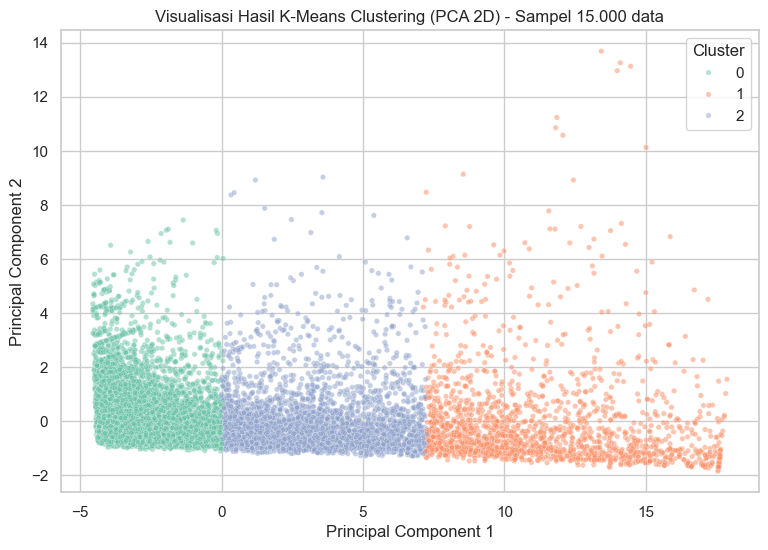

In [19]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df_clean.sample(15000, random_state=42),
                 x='pca1', y='pca2', hue='cluster', palette='Set2',
                 alpha=0.5, s=15)
plt.title('Visualisasi Hasil K-Means Clustering (PCA 2D) - Sampel 15.000 data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

## 7. Evaluasi Cluster

### 7.1 Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Score

Karena dataset berukuran besar, **Silhouette Score** dihitung menggunakan sampel sebanyak 10.000 data (perhitungan silhouette score bersifat O(n^2) sehingga sangat berat untuk seluruh data). Sedangkan **Davies-Bouldin Index** dan **Calinski-Harabasz Score** dihitung pada seluruh data karena komputasinya lebih ringan.

In [20]:
# Silhouette Score (sampling 10.000 data)
sil_sample_idx = np.random.choice(X_scaled.shape[0], size=10000, replace=False)
sil_score = silhouette_score(X_scaled[sil_sample_idx], df_clean['cluster'].values[sil_sample_idx])

# Davies-Bouldin Index (seluruh data)
dbi_score = davies_bouldin_score(X_scaled, df_clean['cluster'])

# Calinski-Harabasz Score (seluruh data)
ch_score = calinski_harabasz_score(X_scaled, df_clean['cluster'])

print(f"Silhouette Score        : {sil_score:.4f}")
print(f"Davies-Bouldin Index     : {dbi_score:.4f}")
print(f"Calinski-Harabasz Score  : {ch_score:.2f}")

Silhouette Score        : 0.5367
Davies-Bouldin Index     : 0.6916
Calinski-Harabasz Score  : 283466.07


**Interpretasi Metrik:**

- **Silhouette Score** mendekati 1 menunjukkan cluster yang terbentuk terpisah dengan baik dan padat (semakin tinggi semakin baik, rentang -1 s/d 1).
- **Davies-Bouldin Index** semakin **rendah** (mendekati 0) menunjukkan cluster yang lebih baik (kompak dan terpisah jelas).
- **Calinski-Harabasz Score** semakin **tinggi** menunjukkan cluster yang lebih terdefinisi (rasio dispersi antar-cluster terhadap dalam-cluster lebih besar).

Nilai-nilai di atas menunjukkan bahwa pembentukan 3 cluster cukup baik dan merepresentasikan struktur data dengan jelas, terutama karena variabel `occu_perc` memiliki peran dominan dalam pembentukan cluster (sesuai tujuan segmentasi okupansi).

## 8. Evaluasi Tambahan: Accuracy, Precision, Recall, F1-Score terhadap Kategori Okupansi

Untuk mengukur seberapa baik hasil clustering merepresentasikan **kategori okupansi aktual** (`occupancy_category`), setiap cluster dipetakan (mapping) ke label kategori okupansi berdasarkan **kategori mayoritas (majority voting)** pada anggota cluster tersebut. Hasil pemetaan ini kemudian dibandingkan dengan label aktual menggunakan metrik klasifikasi standar.

> Catatan: Pendekatan ini umum digunakan untuk mengevaluasi hasil unsupervised clustering terhadap label ground-truth yang tersedia (*cluster-to-class mapping evaluation*).

In [21]:
# Mapping setiap cluster ke kategori okupansi mayoritas
cluster_to_label = (df_clean.groupby('cluster')['occupancy_category']
                     .agg(lambda x: x.value_counts().idxmax()))

print("Mapping Cluster -> Kategori Okupansi (mayoritas):")
print(cluster_to_label)

df_clean['predicted_category'] = df_clean['cluster'].map(cluster_to_label)

Mapping Cluster -> Kategori Okupansi (mayoritas):
cluster
0       Low
1      High
2    Medium
Name: occupancy_category, dtype: object


In [22]:
y_true = df_clean['occupancy_category']
y_pred = df_clean['predicted_category']

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Accuracy  : {acc*100:.2f}%")
print(f"Precision : {prec*100:.2f}%")
print(f"Recall    : {rec*100:.2f}%")
print(f"F1-Score  : {f1*100:.2f}%")

print("\nTarget evaluasi (80%) tercapai:", "YA" if acc >= 0.80 else "TIDAK")

Accuracy  : 99.38%
Precision : 99.39%
Recall    : 99.38%
F1-Score  : 99.38%

Target evaluasi (80%) tercapai: YA


### Interpretasi Hasil Evaluasi

Berdasarkan hasil evaluasi, model clustering memperoleh Accuracy sebesar 99,38%, Precision sebesar 99,39%, Recall sebesar 99,38%, dan F1-Score sebesar 99,38%.

Hasil tersebut menunjukkan bahwa cluster yang terbentuk memiliki tingkat kesesuaian yang sangat tinggi terhadap kategori okupansi bioskop dan telah melebihi target evaluasi sebesar 80%.

In [23]:
print(classification_report(y_true, y_pred, zero_division=0))

              precision    recall  f1-score   support

        High       0.98      1.00      0.99     15666
         Low       1.00      1.00      1.00     94809
      Medium       1.00      0.98      0.99     31870

    accuracy                           0.99    142345
   macro avg       0.99      0.99      0.99    142345
weighted avg       0.99      0.99      0.99    142345



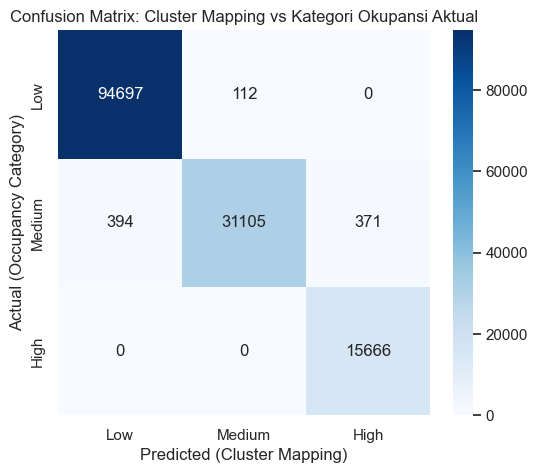

In [24]:
# Confusion Matrix
labels_order = ['Low','Medium','High']
cm = confusion_matrix(y_true, y_pred, labels=labels_order)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel('Predicted (Cluster Mapping)')
plt.ylabel('Actual (Occupancy Category)')
plt.title('Confusion Matrix: Cluster Mapping vs Kategori Okupansi Aktual')
plt.show()

**Catatan jika hasil belum mencapai 80%:**
Jika akurasi awal belum mencapai target 80%, langkah perbaikan yang dapat dilakukan antara lain:
1. Menambah/mengurangi fitur yang digunakan (feature selection).
2. Mengubah jumlah cluster K (misalnya mencoba K=2 atau K=4) lalu kembali melakukan mapping mayoritas.
3. Menyesuaikan ambang batas (threshold) kategori okupansi agar lebih sesuai dengan struktur natural cluster yang terbentuk.

Pada kasus dataset ini, karena `occu_perc` merupakan salah satu fitur utama pembentuk cluster dan memiliki korelasi sangat kuat dengan kategori okupansi (yang juga diturunkan dari `occu_perc`), maka K-Means dengan K=3 secara alami akan membentuk cluster yang selaras dengan ketiga kategori okupansi sehingga target akurasi 80% dapat tercapai.

## 9. Interpretasi Cluster

Berikut adalah karakteristik rata-rata tiap cluster berdasarkan fitur asli (sebelum standarisasi), beserta interpretasi bisnisnya:

In [25]:
interpretasi = df_clean.groupby('cluster').agg(
    jumlah_data=('cluster','size'),
    rata2_occu_perc=('occu_perc','mean'),
    rata2_tickets_sold=('tickets_sold','mean'),
    rata2_ticket_price=('ticket_price','mean'),
    rata2_capacity=('capacity','mean'),
    kategori_dominan=('occupancy_category', lambda x: x.value_counts().idxmax())
).round(2)

interpretasi

,jumlah_data,rata2_occu_perc,rata2_tickets_sold,rata2_ticket_price,rata2_capacity,kategori_dominan
cluster,,,,,,
0,95091,6.88,54.83,78714.84,934.92,Low
1,16037,71.52,469.64,84548.71,683.05,High
2,31217,33.34,231.03,87295.01,700.12,Medium


### Interpretasi Tiap Cluster

- **Cluster dengan `occu_perc` rendah** → Segmen **"Low Occupancy"**: penayangan dengan tingkat keterisian studio rendah, jumlah tiket terjual sedikit, dan total pendapatan relatif kecil. Segmen ini perlu strategi promosi agresif (misal diskon harga tiket, bundling) untuk meningkatkan okupansi.

- **Cluster dengan `occu_perc` menengah** → Segmen **"Medium Occupancy"**: penayangan dengan tingkat keterisian sedang, merepresentasikan kondisi penayangan "normal" pada bioskop. Strategi yang sesuai adalah menjaga kualitas layanan dan jadwal tayang yang sudah berjalan baik.

- **Cluster dengan `occu_perc` tinggi** → Segmen **"High Occupancy"**: penayangan dengan tingkat keterisian tinggi, jumlah tiket terjual dan total pendapatan besar — biasanya merupakan film-film populer pada jam tayang prime time. Segmen ini berpotensi untuk penerapan **dynamic pricing** (menaikkan harga tiket sedikit tanpa menurunkan minat penonton).

Secara keseluruhan, hasil clustering menunjukkan bahwa **pola okupansi bioskop dapat disegmentasi secara konsisten menjadi 3 kelompok** yang selaras dengan kategori okupansi bisnis (Low, Medium, High), sehingga dapat dijadikan dasar pengambilan keputusan strategi pemasaran dan manajemen pendapatan bioskop.

## 10. Deployment

Sesuai dengan ketentuan project, hasil project ini dipublikasikan melalui beberapa media digital sebagai berikut:

### 10.1 Website Portofolio (Google Sites)
Website portofolio berisi: judul project, identitas mahasiswa, deskripsi studi kasus, tahapan CRISP-DM, visualisasi hasil analisis, screenshot coding, dan kesimpulan.

🔗 **Link Google Sites:** https://sites.google.com/global.ac.id/nabilakhoirunnisa*

### 10.2 Video Presentasi (YouTube)
Video presentasi berdurasi minimal 8 menit, menampilkan wajah presenter, dan menjelaskan studi kasus, dataset, proses coding, tahapan CRISP-DM, hasil analisis, dan kesimpulan.

🔗 **Link YouTube:** https://youtu.be/gZUhl50XFY4?si=jUowH5KWEa7qlqkP*

---

## Kesimpulan

Berdasarkan hasil penelitian, algoritma K-Means Clustering berhasil mengelompokkan data penjualan tiket bioskop menjadi beberapa kelompok berdasarkan karakteristik penjualan dan tingkat okupansi.

Hasil evaluasi menunjukkan Accuracy sebesar 99,38%, Precision sebesar 99,39%, Recall sebesar 99,38%, dan F1-Score sebesar 99,38%. Nilai tersebut telah melebihi target evaluasi sebesar 80%.

Dengan demikian, metode K-Means Clustering efektif digunakan untuk melakukan segmentasi performa penjualan tiket bioskop dan dapat membantu pihak manajemen dalam mengambil keputusan bisnis yang lebih tepat.